<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/mock_oppe1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For remaining Part of Mock_1 and Mock_2 :
https://colab.research.google.com/drive/1ZIapxF2XPvTpFtBUV2sZuy0dO9ISsjkD#scrollTo=SYYxXOQF30wX

In [1]:
import pandas as pd
import numpy as np

In [2]:
path='/content/drive/MyDrive/Dataset/NPPE1_Preprocessing1.csv'
df=pd.read_csv(path)

In [3]:
df.head(3)

,CRIM,ZN,INDUS,POLINDEX,RM,AGE,DIS,HIGHWAYCOUNT,TAX,PTRATIO,IMM,BPL,PRICE,RIVERSIDE
0,1.026769,1.429034,7.851300,1.134216,6.0,42.0,5.251911,5,279.201277,20.689586,398.811960,10.461456,22.991633,NO
1,0.848089,0.255543,6.263434,1.245993,7.0,63.0,4.305546,8,307.444529,17.465398,377.153649,11.619690,24.551055,NO
2,10.925905,0.441022,18.322960,2.824833,8.0,-2.0,2.409495,25,666.492973,20.351601,387.061355,19.366070,15.875346,NO


In [4]:
df.shape

(4000, 14)

What is the average house price (in lacs)?

In [6]:
df.PRICE.sum()/df.shape[0]

np.float64(24.355923220694248)

In [9]:
print(df.PRICE.mean())

24.355923220694248


How many houses have 5 or more rooms?

In [12]:
df[df.RM>=5].shape[0]

3953

What is the average price of the top 10 most expensive houses (in lacs)?

In [13]:
df.PRICE.sort_values(ascending=False).head(10).mean()

np.float64(52.36590175716407)

What is the total number of missing or unknown values in the number of rooms feature?

(Hint: carefully look at the values the feature takes and find out implausible value.)

In [14]:
df.RM.unique()

array([ 6.,  7.,  8.,  9., 10., -1.,  5.,  4., 11.])

In [15]:
df.RM.value_counts()

,count
RM,
7.0,1733
6.0,961
8.0,894
9.0,276
5.0,47
10.0,40
-1.0,40
4.0,7
11.0,2


In [16]:
# verifying
df[df['RM']<0].shape[0]

40

What is the total number of missing or unknown values in the age feature?

(Hint: carefully look at the values the feature takes and find out implausible value.)

In [18]:
df['AGE'].unique()

array([ 42.,  63.,  -2.,   9.,  20.,  95.,  35.,  97.,  36.,  78.,  99.,
        96.,  19.,  73.,  86.,  37.,  76.,  50.,  32.,  92., 101.,   8.,
        94.,  84.,  47.,  43.,  65.,  46.,  59.,  74.,  93.,  80.,  98.,
       102.,  56., 100.,  89.,  53.,  18.,  71.,  62.,  83.,  66.,   7.,
        77.,  91.,  90.,  58.,  57.,  60.,  87.,  75.,  34.,  85.,  48.,
        33.,  38.,  30.,  23.,  55.,  11.,  14.,  45.,  41.,  88.,  16.,
        12.,  79.,  67.,  39.,  49.,  61.,  70.,  54.,  10.,  22.,  72.,
        15.,  51.,  81.,  31.,  52.,  44.,  28.,  17.,  40.,  29.,  69.,
        64.,  24.,  82.,  26.,  68.,  27.,  13., 103.,  21.,  25.,   6.,
         5.,   3.,   4.])

In [26]:
df[df['AGE']<=0].shape[0]

50

In [31]:
(df['AGE']<=0).value_counts()

,count
AGE,
False,3950
True,50


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


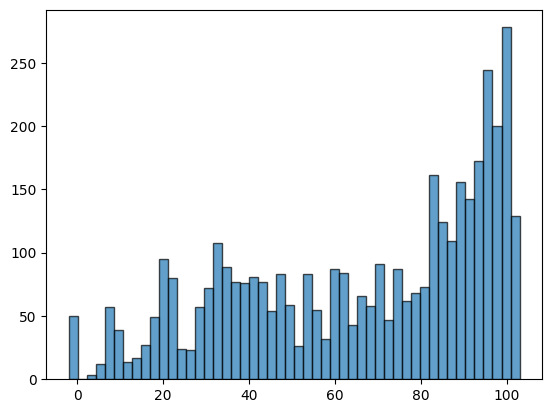

In [28]:
plt.hist(df['AGE'],bins=50,edgecolor='black',alpha=0.7)
plt.show()

What is the total number of missing or unknown values in the RIVERSIDE feature?

(Hint: carefully look at the values the feature takes and find out implausible value.)

In [32]:
df['RIVERSIDE'].unique()

array(['NO', 'UNKNOWN', 'YES'], dtype=object)

In [33]:
df['RIVERSIDE'].value_counts()

,count
RIVERSIDE,
NO,3595
YES,317
UNKNOWN,88


How many houses are on riverside and were built within the last 50 years (i.e. a house 50 years old or younger)? For this question, ignore the rows that have missing values in either riverside feature or age feature.

In [34]:
df[(df['RIVERSIDE']=='YES') & (df['AGE']>0) &(df['AGE']<=50)].shape[0]

44

How many houses are near to exactly 6, 7 or 8 highways (all three inclusive)?

In [36]:
df['HIGHWAYCOUNT'].unique()

array([ 5,  8, 25,  4,  1,  6,  7,  2, 24,  3, 26, 10,  9, 11, 27])

In [37]:
df[(df['HIGHWAYCOUNT']==6) | (df['HIGHWAYCOUNT']==7) |(df['HIGHWAYCOUNT']==8)].shape[0]

1211

Create a column 'CATEGORY' and divide the houses in categories as following:

- Category 1: house price <10 lacs
- Category 2: 10 lacs <= house price <20 lacs
- Category 3: 20 lacs <= house price <30 lacs
- Category 4: 30 lacs <= house price <40 lacs
- Category 5: house price >=40 lacs

Which category has the highest number of records?

In [39]:
def category(price):
    if price <10:
        return "Category 1"
    elif 10<=price <20:
        return "Category 2"
    elif 20<=price <30:
        return "Category 3"
    elif 30<=price <40:
        return "Category 4"
    else:
        return "Category 5"

In [40]:
df['CATEGORY']=df['PRICE'].map(category)

In [42]:
df['CATEGORY'].unique()

array(['Category 3', 'Category 2', 'Category 5', 'Category 4',
       'Category 1'], dtype=object)

In [43]:
df.tail()

,CRIM,ZN,INDUS,POLINDEX,RM,AGE,DIS,HIGHWAYCOUNT,TAX,PTRATIO,IMM,BPL,PRICE,RIVERSIDE,CATEGORY
3995,4.366543,1.159592,22.230240,1.146936,6.0,96.0,2.332414,6,403.809266,15.810504,354.065893,21.902957,16.375222,NO,Category 2
3996,9.132894,0.294115,18.741019,0.876901,6.0,100.0,2.509486,24,666.000417,20.548310,394.997535,19.940826,9.565996,NO,Category 1
3997,0.859468,21.201881,4.098201,1.142168,7.0,102.0,2.187747,7,264.067049,14.606753,392.096041,7.669832,30.106096,NO,Category 4
3998,0.587681,45.399856,3.706238,1.719303,8.0,22.0,7.631113,6,398.613388,16.722867,378.734812,6.364646,37.403409,NO,Category 4
3999,5.143827,0.000920,18.599543,0.864198,7.0,89.0,3.720523,24,666.587599,22.423092,392.552040,14.793550,20.204362,NO,Category 3


In [44]:
df['CATEGORY'].value_counts()

,count
CATEGORY,
Category 3,2028
Category 2,1158
Category 4,503
Category 5,268
Category 1,43


- 1. Replace the respective missing or unknown values in features room count, riverside and age with np.nan.
- 2. Keep 30% of the data as test set.
- 3. Use random_state as 0
- 4. PRICE is the target, rest of the columns are the features.
- 5. Apply train test split.
- Hint: look for the documentation of the usual function that divides  the data into training and test datasets.

What is the number of samples in the training set?

In [45]:
df['RM'].unique()

array([ 6.,  7.,  8.,  9., 10., -1.,  5.,  4., 11.])

In [46]:
df['RM']=df['RM'].replace(-1,np.nan)

In [47]:
df['RIVERSIDE'].unique()

array(['NO', 'UNKNOWN', 'YES'], dtype=object)

In [48]:
df['RIVERSIDE']=df['RIVERSIDE'].replace('UNKNOWN',np.nan)

In [49]:
df["AGE"].unique()

array([ 42.,  63.,  -2.,   9.,  20.,  95.,  35.,  97.,  36.,  78.,  99.,
        96.,  19.,  73.,  86.,  37.,  76.,  50.,  32.,  92., 101.,   8.,
        94.,  84.,  47.,  43.,  65.,  46.,  59.,  74.,  93.,  80.,  98.,
       102.,  56., 100.,  89.,  53.,  18.,  71.,  62.,  83.,  66.,   7.,
        77.,  91.,  90.,  58.,  57.,  60.,  87.,  75.,  34.,  85.,  48.,
        33.,  38.,  30.,  23.,  55.,  11.,  14.,  45.,  41.,  88.,  16.,
        12.,  79.,  67.,  39.,  49.,  61.,  70.,  54.,  10.,  22.,  72.,
        15.,  51.,  81.,  31.,  52.,  44.,  28.,  17.,  40.,  29.,  69.,
        64.,  24.,  82.,  26.,  68.,  27.,  13., 103.,  21.,  25.,   6.,
         5.,   3.,   4.])

In [50]:
df['AGE']=df['AGE'].replace(-2,np.nan)

In [51]:
feature=df.drop('PRICE',axis=1)
labels=df['PRICE'].copy()
feature.shape,labels.shape

((4000, 14), (4000,))

In [52]:
from sklearn.model_selection import  train_test_split
X_train,X_test,y_train,y_test=train_test_split(feature,labels,random_state=0,test_size=0.3)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(2800, 14) (2800,)
(1200, 14) (1200,)
